In [2]:
import numpy as np
import random
import torch
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt

In [10]:
def generate_ts(len):
    tf = 80 * np.pi
    t = np.linspace(0., tf, len)
    y = np.sin(t) + 0.8 * np.cos(.5 * t) + np.random.normal(0., 0.3, len) + 2.5
    return y.tolist()

def sliding_window(ts, features, target_len = 1):
    X = []
    Y = []

    for i in range(features + target_len, len(ts) + 1):
        X.append(ts[i - (features + target_len):i - target_len])
        Y.append(ts[i - target_len:i])

    return X, Y

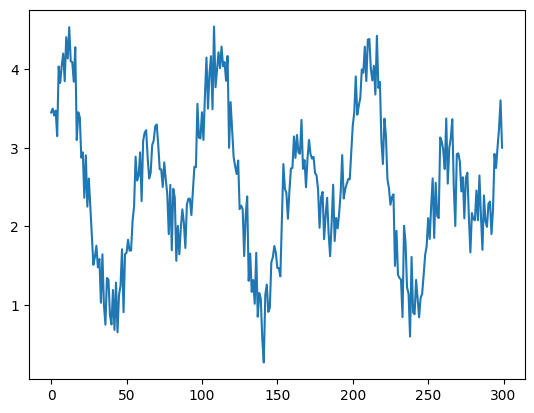

In [11]:
ts = generate_ts(2000)
plt.plot(ts[:300])
plt.show()

# LSTM Encoder 

Conventions for Encoder module

- `x` $\in \mathbb{R}^{L \times N \times H_{in}}$ (by default `batch_first=False`)
- `out` $\in \mathbb{R}^{L \times N \times H_{out}}$
- `h` is a tuple: `(hout, c)`
- `hout` $\in \mathbb{R}^{K \times N \times H_{out}}$

where

- $N$: Batch size
- $L$: Sequence Length
- $K$: `num_layers`
- $H_{in}$: `input_size`
- $H_{out}$: `hidden_size`

In [14]:
class Encoder(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers = 1):
        super(Encoder, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers)

    def forward(self, x):
        flat = x.view(x.shape[0], x.shape[1], self.input_size)
        out, h = self.lstm(flat)
        return out, h

# LSTM Decoder

Conventions for Decoder module

- `x` $\in \mathbb{R}^{N \times H_{in}}$ 
- `x.unsqueeze(0)` $\in \mathbb{R}^{1 \times N \times H_{in}}$ 
- `out` $\in \mathbb{R}^{1 \times N \times H_{out}}$ 
- `out.squeeze(0)` $\in \mathbb{R}^{N \times H_{out}}$ 
- `y` $\in \mathbb{R}^{N \times P}$ 
- `h` is a tuple: `(hout, c)`
- `hout` and `c` $\in \mathbb{R}^{K \times N \times H_{out}}$

where:

- $N$: Batch size
- $P$: `output_size`
- $K$: `num_layers`
- $H_{in}$: `input_size`
- $H_{out}$: `hidden_size`

In [12]:
class Decoder(nn.Module):

    def __init__(self, input_size, hidden_size, output_size = 1, num_layers = 1):
        super(Decoder, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size

        self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x, h):
        out, h = self.lstm(x.unsqueeze(0), h)
        y = self.linear(out.squeeze(0))
        return y, h

# Encoder-Decoder architecture

Conventions for Encoder-Decoder module

- `train` $\in \mathbb{R}^{L \times N \times H_{in}}$ (by default `batch_first=False`)
- `dec_in` $\in \mathbb{R}^{N \times H_{out}}$, picks the last sequence in `train`
- `enc_h` $=$ `dec_h` is a tuple: `(f, c)` 
- `f` and `c` $\in \mathbb{R}^{K \times N \times H_{out}}$

where

- $N$: Batch size
- $L$: Sequence Length
- $K$: `num_layers`
- $P$: `output_size`
- $H_{in}$: `input_size`
- $H_{out}$: `hidden_size`

In [15]:
class EncoderDecoder(nn.Module):

    def __init__(self, hidden_size, input_size = 1, output_size = 1):
        super(EncoderDecoder, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.encoder = Encoder(input_size = input_size, hidden_size = hidden_size)
        self.decoder = Decoder(input_size = input_size, hidden_size = hidden_size, output_size = output_size)

    def train_model(
            self, train, target, epochs, target_len, method = 'recursive',
            tfr = 0.5, lr = 0.01, dynamic_tf = False
    ):
        losses = np.full(epochs, np.nan)
        optimizer = optim.Adam(self.parameters(), lr = lr)
        criterion = nn.MSELoss()

        for e in range(epochs):
            predicted = torch.zeros(target_len, train.shape[1], train.shape[2])
            optimizer.zero_grad()
            _, enc_h = self.encoder(train)

            dec_in = train[-1, :, :]
            dec_h = enc_h

            if method == 'recursive':
                for t in range(target_len):
                    dec_out, dec_h = self.decoder(dec_in, dec_h)
                    predicted[t] = dec_out
                    dec_in = dec_out

            if method == 'teacher_forcing':
                # use teacher forcing
                if random.random() < tfr:
                    for t in range(target_len):
                        dec_out, dec_h = self.decoder(dec_in, dec_h)
                        predicted[t] = dec_out
                        dec_in = target[t, :, :]
                # predict recursively
                else:
                    for t in range(target_len):
                        dec_out, dec_h = self.decoder(dec_in, dec_h)
                        predicted[t] = dec_out
                        dec_in = dec_out

            if method == 'mixed_teacher_forcing':
                # predict using mixed teacher forcing
                for t in range(target_len):
                    dec_out, dec_h = self.decoder(dec_in, dec_h)
                    predicted[t] = dec_out
                    # predict with teacher forcing
                    if random.random() < tfr:
                        dec_in = target[t, :, :]
                    # predict recursively
                    else:
                        dec_in = dec_out

            loss = criterion(predicted, target)
            loss.backward()
            optimizer.step()

            losses[e] = loss.item()

            if e % 10 == 0:
                print(f'Epoch {e}/{epochs}: {round(loss.item(), 4)}')

            # dynamic teacher forcing
            if dynamic_tf and tfr > 0:
                tfr = tfr - 0.02

        return losses

    def predict(self, x, target_len):
        y = torch.zeros(target_len, x.shape[1], x.shape[2])

        _, enc_h = self.encoder(x)
        dec_in = x[-1, :, :]
        dec_h = enc_h

        for t in range(target_len):
            dec_out, dec_h = self.decoder(dec_in, dec_h)
            y[t] = dec_out
            dec_in = dec_out

        return y

# Set random seed for reproducibility

In [7]:
seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Define parameters

In [8]:
ts_len = 2000 # synthetic time series length
hidden_size = 64 # lstm hidden size
test_ds_len = 200 # test dataset size
epochs = 500 # training epochs
ts_history_len = 240 # input history (features)
ts_target_len = 60 # prediction length

# Create dataset for training and test

In [16]:
ts = generate_ts(ts_len)
X, Y = sliding_window(ts, ts_history_len, ts_target_len)
ds_len = len(X)

def to_tensor(data):
    return torch.tensor(data = data)\
        .unsqueeze(2)\
        .transpose(0, 1).float()

x_train = to_tensor(X[:ds_len - test_ds_len])
y_train = to_tensor(Y[:ds_len - test_ds_len])
x_test = to_tensor(X[ds_len - test_ds_len:])
y_test = to_tensor(Y[ds_len - test_ds_len:])

In [22]:
print(f"ts len: {len(ts)}, X len: {len(X)}, X[0] len: {len(X[0])}")

ts len: 2000, X len: 1701, X[0] len: 240


# Shape of train sets

In [23]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")

x_train shape: torch.Size([240, 1501, 1])
y_train shape: torch.Size([60, 1501, 1])


# Create model

In [ ]:
model = EncoderDecoder(hidden_size = hidden_size)

# Train the model

In [ ]:
model.train()
model.train_model(x_train, y_train, epochs, ts_target_len,
                  method = 'mixed_teacher_forcing',
                  tfr = .05, lr = .005)

# Evaluate on test set

In [ ]:
model.eval()
predicted = model.predict(x_test, ts_target_len)

# Plot results

In [ ]:
fig, ax = plt.subplots(nrows = 3, ncols = 1)
fig.set_size_inches(7.5, 6)
for col in ax:
    r = random.randint(0, test_ds_len)
    in_seq = x_test[:, r, :].view(-1).tolist()
    target_seq = y_test[:, r, :].view(-1).tolist()
    pred_seq = predicted[:, r, :].view(-1).tolist()
    x_axis = range(len(in_seq) + len(target_seq))
    col.set_title(f'Test Sample: {r}')
    col.axis('off')
    col.plot(x_axis[:], in_seq + target_seq, color = 'blue')
    col.plot(x_axis[len(in_seq):],
             pred_seq,
             label = 'predicted',
             color = 'orange',
             linestyle = '--',
             linewidth = 3)
    col.vlines(len(in_seq), 0, 6, color = 'grey')
    col.legend(loc = "upper right")

plt.show()